In [ ]:
# system imports
import re
from pathlib import Path

# torch imports
import torch
from lightning import LightningModule, Trainer
from lightning.pytorch.callbacks import EarlyStopping

# project imports 
from core.models import DeepReLUClassifier 
from core.data import MNISTLightningDataModule 
from core.bias import RidgeBias 
from core.estimators import BiasWithCrossEntropy 
from core.wandb_utils import wandb_summary_df

# wandb imports
import wandb
import pandas as pd

# data visualization imports
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from core.plotting import panelplot
plt.style.use("../clean_fig.mplstyle")


## Access previous runs

In [ ]:
api = wandb.Api(timeout=60)
user_org = "jhrudoler-penn"
project_name = "inductive-bias"
sweep_id = "2stzqc65"
sweep = api.sweep(f"{user_org}/{project_name}/{sweep_id}")
runs = sweep.runs  # automatically filtered to that sweep

def download_checkpoint(run, alias="best"):  # alias "latest" or explicit step also works
    artifacts = run.logged_artifacts()
    model_artifacts = [a for a in artifacts if a.type == "model"]
    # pick the latest matching alias
    for artifact in sorted(model_artifacts, key=lambda a: a.created_at, reverse=True):
        if alias in artifact.aliases:
            artifact_dir = artifact.download()
            # Lightning checkpoints are usually named `model.ckpt`
            return Path(artifact_dir) / "model.ckpt"
    raise FileNotFoundError(f"No checkpoint with alias '{alias}' for run {run.name}")

def load_model_from_run(run):
    cfg = run.config
    print(cfg)
    model = DeepReLUClassifier(
        input_dim=28*28,
        width=cfg["width"],
        depth=cfg["depth"],
        dropout=cfg["dropout"],
        batchnorm=cfg["batchnorm"],
        lr=cfg["lr"],
        momentum=cfg["momentum"],
        l2_penalty=cfg["l2_penalty"],
    )
    ckpt_path = download_checkpoint(run, alias="best")  # or "latest"
    state_dict = torch.load(ckpt_path, map_location="cpu")
    model.load_state_dict(state_dict["state_dict"])
    model.eval()
    return model

In [ ]:
def fit_bias_for_run(run):
    model = load_model_from_run(run)
    # Build whichever bias model(s) you want
    bias_model = RidgeBias()
    estimator = BiasWithCrossEntropy(
        predictive_model=model.eval(),
        bias_model=bias_model,
    )
    dm = MNISTLightningDataModule(root="~/inductive-bias/MNIST", batch_size=run.config["batch_size"], num_workers=run.config.get("num_workers", 4))
    trainer = Trainer(max_epochs=200, accelerator="auto", devices=1, callbacks=[EarlyStopping(monitor="train/loss", patience=20)])
    dm.setup("fit")
    trainer.fit(estimator, datamodule=dm)
    return bias_model.get_bias_params()

In [ ]:
# get df of run configs and metrics

rows = []
for run in runs:
    # get run config
    config = run.config
    # get run metrics
    metrics = run.summary
    # append to rows
    rows.append({"run_id": run.id, **config, **metrics})
df_summary = pd.DataFrame(rows)
df_summary.head()


In [ ]:
df_summary["depth"].value_counts()

In [ ]:
# Seaborn faceted plot of estimated_ridge as a function of dropout, facets covering different depths
sns.lineplot(data=df_summary, x="dropout", y="estimated_ridge", hue="depth")


## Re-fit bias models

In [ ]:
rows = []
for run in runs:
    try:
        bias_value = fit_bias_for_run(run)
        rows.append({"run_id": run.id, "seed": run.config["seed"], "dropout": run.config["dropout"], "bias": bias_value})
    except Exception as exc:
        print(f"Skipping {run.name}: {exc.__class__.__name__}: {exc}")

df = pd.DataFrame(rows)
df.head()

## Visualize sweep results

In [ ]:
# get df of run configs and metrics
# no max columns
pd.set_option("display.max_columns", None)

sweep_id = "3ueveg4e"
user_org = "jhrudoler-penn"
project_name = "inductive-bias-experiments"
full_sweep_id = f"{user_org}/{project_name}/{sweep_id}"
api = wandb.Api(timeout=60)
sweep = api.sweep(full_sweep_id)
runs = sweep.runs

rows = []
for run in runs:
    # check that the run is finished
    if run.state != "finished":
        continue
    # get run config
    config = run.config
    # get run metrics
    metrics = run.summary
    # get run system metrics
    system_metrics = run.system_metrics
    # get run gpu memory and utilization by regex
    system_metrics = {k: v for k, v in system_metrics.items() if re.match(r"^system\.gpu\.\d+\.(gpu|memory)$", k)}
    # append to rows
    rows.append({"run_id": run.id, **config, **metrics, **system_metrics})
df_summary = pd.DataFrame(rows)
df_summary.head()

In [ ]:
[k for k in run.history_keys['keys'] if "gpu" in k]

In [ ]:
# history of gpu memory and utilization
gpu_history = run.history(keys=[k for k in run.history_keys['keys'] if "gpu" in k])
gpu_history.head()


In [ ]:
system_metrics_df = pd.DataFrame()
for run in runs:
    # get run system metrics
    system_metrics = run.system_metrics
    # get run gpu memory and utilization
    # make a df with columns for each metric matching system.gpu.*.gpu and system.gpu.*.memory
    # filter out other metrics
    system_metrics_df = pd.concat([system_metrics_df, pd.DataFrame(system_metrics, index=[0])])
system_metrics_df["run_id"] = [run.id for run in runs]
system_metrics_df = system_metrics_df.filter(regex=r"^system\.gpu\.\d+\.(gpu|memory)$")
# rename columns to remove the system.gpu. prefix
system_metrics_df.columns = [col.replace("system.", "") for col in system_metrics_df.columns]
system_metrics_df

In [ ]:
# gpu memory and utilization
df_summary.columns

In [ ]:
# scatterplot of l2/true vs l2/estimated
ax = sns.scatterplot(
    data=df_summary, 
    x="l2/true", 
    y="l2/estimated", 
    hue="train_bias/loss", 
    style="depth",
    alpha=0.5
)
ax.set_xscale("log")
ax.set_yscale("log")
# add 1:1 line
ax.plot(
    [min(df_summary["l2/true"]), max(df_summary["l2/true"])],
    [min(df_summary["l2/true"]), max(df_summary["l2/true"])],
    color="k",
    linestyle="--",
)


In [ ]:
# facetgrid of l2/true vs l2/estimated, facets covering different depths
facet_data = df_summary.query("`l2/true` < 0.1")
g = sns.FacetGrid(facet_data, col="depth", col_wrap=3)
# color by train/loss, remove the default colorbar      
g.map_dataframe(sns.scatterplot, x="l2/true", y="l2/estimated", c="train/loss",)
# show colorbar
g.set(xscale="log", yscale="log")
# add 1:1 line to each facet
def refline(x,**kwargs):
    plt.plot(
        [min(x), max(x)],
        [min(x), max(x)],
        color="k",
        linestyle="--",
    )
g.map(refline, "l2/true")


In [ ]:
df_summary.groupby(["l2/true", "depth"]).agg({"l2/rel_error": "mean", "train/acc": "mean"})
df_summary.groupby(["l2/true", "depth"]).count()

In [ ]:

# helper function to get full trajectory of train_bias/loss from run
def get_train_bias_loss_trajectory(run):
    # get train_bias/loss from run
    train_bias_loss = run.history(keys=["train/loss", "train/acc"], pandas=True)
    # return as dataframe
    return train_bias_loss

losses = get_train_bias_loss_trajectory(runs[0])



In [ ]:
# plot train/loss and train/acc on separate subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
losses["train/loss"].plot(ax=ax1)
ax1.axhline(y=0.0, color="k", linestyle="--")
losses["train/acc"].plot(ax=ax2)
plt.axhline(y=0.0, color="k", linestyle="--")
plt.show()


## For dropout sweep

In [ ]:
sweep_id = "chiy2qjz"
user_org = "jhrudoler-penn"
project_name = "inductive-bias"
full_sweep_id = f"{user_org}/{project_name}/{sweep_id}"
api = wandb.Api(timeout=60)
sweep = api.sweep(full_sweep_id)
runs = sweep.runs

In [ ]:
for a in runs[0].logged_artifacts():
    path = a.download(root=Path("~/inductive-bias/logs").expanduser() / "artifacts" / a.name)
    print(path)


In [ ]:
df_dropout_summary = wandb_summary_df(runs)
# remove depth=1 run which did not apply dropout
df_dropout_summary = df_dropout_summary[df_dropout_summary["depth"] != 1]
df_dropout_summary.head()

In [ ]:
g = sns.FacetGrid(
    df_dropout_summary,
    col="width",
    row="depth",
    sharex=True,
    sharey=True,
    margin_titles=True,
    height=2.5,
    aspect=1,
)
g.map_dataframe(panelplot, x="dropout", y="estimated_ridge", hue="train_bias/loss")

# add colorbar
cax = g.figure.add_axes([1.05, 0.1, 0.02, 0.8])
norm = mpl.colors.Normalize(
    vmin=df_dropout_summary["train_bias/loss"].min(),
    vmax=df_dropout_summary["train_bias/loss"].max(),
)
sm = plt.cm.ScalarMappable(cmap="Blues", norm=norm)
sm.set_array([])
cbar = g.figure.colorbar(sm, cax=cax)
cbar.set_label("train_bias/loss")

g.set_axis_labels("dropout", "estimated_ridge")
# rotate x-axis labels
g.tick_params(axis="x", rotation=45)
plt.savefig("../results/figures/dropout_bias_ridge_panel.png", dpi=300)

In [ ]:
# same figure but with val/acc on the y-axis
g = sns.FacetGrid(
    df_dropout_summary,
    col="width",
    row="depth",
    sharex=True,
    sharey=True,
    margin_titles=True,
    height=2.5,
    aspect=1,
)
g.map_dataframe(panelplot, x="dropout", y="val/acc")
g.set_axis_labels("dropout", "val/acc")
g.tick_params(axis="x", rotation=45)
plt.savefig("../results/figures/dropout_bias_ridge_panel_val_acc.png", dpi=300)

In [ ]:
# same with train/acc on the y-axis
g = sns.FacetGrid(
    df_dropout_summary,
    col="width",
    row="depth",
    sharex=True,
    sharey=True,
    margin_titles=True,
    height=2.5,
    aspect=1,
)
g.map_dataframe(panelplot, x="dropout", y="train/acc")
g.set_axis_labels("dropout", "train/acc")
g.tick_params(axis="x", rotation=45)
plt.savefig("../results/figures/dropout_bias_ridge_panel_train_acc.png", dpi=300)


## Mixed bias

In [ ]:
sweep_id = "00rb3gsn"
user_org = "jhrudoler-penn"
project_name = "inductive-bias"
full_sweep_id = f"{user_org}/{project_name}/{sweep_id}"
api = wandb.Api(timeout=60)
sweep = api.sweep(full_sweep_id)
runs = sweep.runs

df_mixed_summary = wandb_summary_df(runs)

# wide to long stacking estimated_ridge and estimated_nuclear_norm
df_mixed_summary = pd.melt(
    df_mixed_summary,
    id_vars=["run_id", "width", "depth", "dropout", "seed", "train_bias/loss", "train/acc", "val/acc", "train_bias/bias_models.0.beta_grad", "train_bias/bias_models.1.beta_grad"],
    value_vars=["estimated_ridge", "estimated_nuclear_norm"],
    var_name="bias_type",
    value_name="estimated_bias",
)


In [ ]:
g = sns.FacetGrid(
    df_mixed_summary,
    col="width",
    row="bias_type",
    sharex=True,
    sharey=True,
    margin_titles=True,
)
g.map_dataframe(panelplot, x="dropout", y="estimated_bias", hue="train_bias/loss")

# add colorbar
cax = g.figure.add_axes([1.05, 0.1, 0.02, 0.8])
norm = mpl.colors.Normalize(
    vmin=df_mixed_summary["train_bias/loss"].min(),
    vmax=df_mixed_summary["train_bias/loss"].max(),
)
sm = plt.cm.ScalarMappable(cmap="Blues", norm=norm)
sm.set_array([])
cbar = g.figure.colorbar(sm, cax=cax)
cbar.set_label("train_bias/loss")
plt.tight_layout()


In [ ]:
p = torch.nn.Parameter(torch.empty(1, 1), requires_grad=True)
torch.nn.init.kaiming_normal_(p.data)
print(p.data)
# accumulate grad in short training loop
optimizer = torch.optim.SGD([p], lr=0.01)
ref = torch.tensor(5.0)
loss_fn = torch.nn.MSELoss()
for i in range(10):
    optimizer.zero_grad()
    loss = loss_fn(p, ref)
    loss.backward()
    print(p.grad, p.data)
    optimizer.step( )
p.grad.zero_()
print(p.grad)

In [ ]:
# test how collinear the grads of the bias models for ridge and nuclear norm are
from core.bias import RidgeBias, NuclearNormBias, JointBias
from lightning.pytorch.callbacks import Callback
from lightning.pytorch import Trainer, LightningModule
from core.estimators import BiasWithMSE
from torch.utils.data import TensorDataset, DataLoader

ridge_bias = RidgeBias()
nuclear_norm_bias = NuclearNormBias()
joint_bias = JointBias([ridge_bias, nuclear_norm_bias])

# create a random weight matrix
weight_vector = torch.randn(10)

n_samples = 100
input = torch.randn(n_samples, 10)
# linear relationship between input and target
target = input @ weight_vector + torch.randn(n_samples)
dataset = TensorDataset(input, target)
dataloader = DataLoader(dataset, batch_size=10)
# compute the grads of the bias models

# train a linear layer to predict target from input
net = torch.nn.Sequential(torch.nn.Linear(10, 10), torch.nn.ReLU(), torch.nn.Linear(10, 1))


# get the spectrum of the weights of each 

# optimizer = torch.optim.SGD(linear.parameters(), lr=0.01)
# for i in range(10):
#     optimizer.zero_grad()
#     loss = loss_fn(linear(input), target)
#     loss.backward()
#     optimizer.step()

estimator = BiasWithMSE(
    predictive_model=net,
    bias_model=joint_bias,
    lr=0.1,
)

# callback to print the cosine similarity between the grads of the bias models
# should be called on each batch
# class PrintBiasGrads(Callback):
#     def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
#         # Access the beta parameters from the joint bias model
#         beta_grads = []
#         for bias_module in pl_module.bias_model.bias_models:
#             if hasattr(bias_module, 'beta') and bias_module.beta.grad is not None:
#                 beta_grads.append(bias_module.beta.grad.item())
        
#         if len(beta_grads) >= 2:
#             # Log individual gradients
#             pl_module.log("grad_beta0", beta_grads[0], prog_bar=True)
#             pl_module.log("grad_beta1", beta_grads[1], prog_bar=True)
            
#             # Log the ratio (another way to see if they're proportional)
#             if abs(beta_grads[1]) > 1e-8:
#                 ratio = beta_grads[0] / beta_grads[1]
#                 pl_module.log("grad_ratio", ratio, prog_bar=True)

# trainer = Trainer(max_epochs=100, callbacks=[PrintBiasGrads()])
# trainer.fit(estimator, dataloader)




In [ ]:
class CheckPenaltyCorrelation(Callback):
    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
        X, y = batch
        
        # Get flattened params (same as in training_step)
        params = dict(pl_module.predictive_model.named_parameters())
        flattened_params = torch.cat([p.view(-1) for p in params.values()])
        flattened_params = flattened_params.detach().requires_grad_()
        
        # Recreate named_param_views
        offset = 0
        named_param_views = {}
        for name, param in params.items():
            numel = param.numel()
            view = flattened_params[offset : offset + numel].view_as(param)
            named_param_views[name] = view
            offset += numel
        
        # Compute individual penalties
        ridge_penalty = torch.sum(flattened_params.pow(2))
        nuclear_penalty = sum(
            torch.linalg.matrix_norm(
                p if p.ndim == 2 else p.reshape(p.shape[0], -1), ord="nuc"
            )
            for p in named_param_views.values() if p.ndim >= 2
        )
        
        # Get their gradients w.r.t. parameters
        grad_ridge = torch.autograd.grad(
            ridge_penalty, flattened_params, create_graph=False
        )[0]
        grad_nuclear = torch.autograd.grad(
            nuclear_penalty, flattened_params, create_graph=False
        )[0]
        
        # Compute cosine similarity
        cos_sim = torch.nn.functional.cosine_similarity(
            grad_ridge.unsqueeze(0), 
            grad_nuclear.unsqueeze(0)
        )
        
        pl_module.log("penalty_grad_correlation", cos_sim.item(), prog_bar=True)
class CheckBiasParams(Callback):
    def on_train_batch_end(self, trainer, pl_module, outputs, batch, batch_idx):
        for bias_model in pl_module.bias_model.bias_models:
            for param in bias_model.parameters():
                pl_module.log(f"{bias_model.__class__.__name__}.{param.name}", param.data.item(), prog_bar=True)

trainer = Trainer(max_epochs=100, callbacks=[CheckPenaltyCorrelation(), CheckBiasParams()], accelerator="cpu")
trainer.fit(estimator, dataloader)

In [ ]:
# Test with matrices of different ranks
import torch

n_samples = 100
n_features = 30


for n_features in [5, 10, 20, 30]:
    rank = n_features
    # Create matrix with specific condition number
    U, _ = torch.linalg.qr(torch.randn(n_samples, n_features))
    V, _ = torch.linalg.qr(torch.randn(n_features, n_features))
    
    # control the rank of the matrix and pad with zeros
    sigma = torch.linspace(10, 1, rank) 
    sigma = torch.cat([sigma, torch.zeros(n_features - rank)])
    # print(sigma)
    W = U @ torch.diag(sigma) @ V.T
    # print(W.shape)
    
    # Compute gradients
    grad_l2 = 2 * W
    
    # Nuclear norm gradient (requires autograd)
    W_param = W.detach().requires_grad_()
    nuclear = torch.linalg.matrix_norm(W_param, ord='nuc')
    nuclear.backward()
    grad_nuclear = W_param.grad

    # canonical nuclear norm grad (singular values change in the 
    # direction of the singular vector outer product)
    grad_nuclear_canonical = U @ V.T
    
    # Correlation
    cos_sim = torch.nn.functional.cosine_similarity(
        grad_l2.flatten().unsqueeze(0),
        grad_nuclear.flatten().unsqueeze(0)
    )

    cos_sim_canonical = torch.nn.functional.cosine_similarity(
        grad_l2.flatten().unsqueeze(0),
        grad_nuclear_canonical.flatten().unsqueeze(0)
    )

    print(torch.allclose(grad_nuclear, grad_nuclear_canonical, atol=1e-6))
    
    print(f"Rank: {rank:6.1f}, Bound 1/sqrt(r): {1/torch.sqrt(torch.tensor(rank)):.8f}, Correlation: {cos_sim.item():.8f}, Canonical: {cos_sim_canonical.item():.8f}")

In [ ]:
# plot the difference in direction of 
# the grads of the l2 and nuclear norm penalties
# l2 grad is 2W=2Udiag(sigma)V^T
# nuclear grad is UV^T
# show geometrically the difference in direction

# pca of grad_l2 and grad_nuclear to 2d for plotting
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
grad_l2_pca = pca.fit_transform(grad_l2)
grad_nuclear_pca = pca.fit_transform(grad_nuclear)


In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.arrow(0, 0, grad_l2_pca[0,0], grad_l2_pca[0,1], head_width=0.01, head_length=0.01, color='r')
plt.arrow(0, 0, grad_nuclear_pca[0,0], grad_nuclear_pca[0,1], head_width=0.01, head_length=0.01, color='b')
plt.xlabel('L2 Grad')
plt.ylabel('Nuclear Grad')
plt.title('Geometric Difference between L2 and Nuclear Gradients')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.arrow(0, 0, grad_l2[1,0], grad_l2[1,1], head_width=0.01, head_length=0.01, color='r')
plt.arrow(0, 0, grad_nuclear[1,0], grad_nuclear[1,1], head_width=0.01, head_length=0.01, color='b')
plt.xlabel('L2 Grad')
plt.ylabel('Nuclear Grad')
plt.title('Geometric Difference between L2 and Nuclear Gradients')
plt.show()

In [ ]:
import torch

def canonical_nuclear_grad(W):
    U, S, Vt = torch.linalg.svd(W, full_matrices=False)
    return U @ Vt

def make_spectrum(rank, spike_ratio=100):
    """
    spike_ratio = sigma_max / sigma_min
    If spike_ratio = 1       → flat
    If spike_ratio = 1e6+    → very spiky
    """
    s = torch.logspace(0, -torch.log10(torch.tensor(float(spike_ratio))), rank)
    s = 10 * s / s.max()      # scale max to 10
    return s

n_samples = 300
n_features = 30

for r in [5, 10, 20, 30]:
    # r = n_features

    # RANDOM ORTHONORMAL FACTORS
    U, _ = torch.linalg.qr(torch.randn(n_samples, n_features))
    V, _ = torch.linalg.qr(torch.randn(n_features, n_features))

    # ***** CRITICAL PART: MAKE SPECTRUM VERY SPIKY *****
    # One large singular value, rest tiny
    # sigma = torch.zeros(n_features)
    # sigma[0] = 10.0                # dominant
    # sigma[1:] = 0.01               # tiny
    sigma = make_spectrum(rank, 1.5)
    # pad with zeros to n_features
    sigma = torch.cat([sigma, torch.zeros(n_features - rank)])

    # Construct matrix
    W = U @ torch.diag(sigma) @ V.T

    # Gradients
    grad_l2 = 2 * W
    grad_nuc_canonical = canonical_nuclear_grad(W)

    # Cosine similarity
    cos = torch.nn.functional.cosine_similarity(
        grad_l2.flatten().unsqueeze(0),
        grad_nuc_canonical.flatten().unsqueeze(0),
        dim=1
    ).item()

    print(f"Rank {r:2d} | 1/sqrt(r) bound = {1/ (r**0.5):.4f} | cosine = {cos:.8f}")

In [ ]:
spec = make_spectrum(30, 10)
mean_spec = spec.mean()
rms_spec = torch.sqrt(spec.pow(2).mean())
print(f"Mean: {mean_spec:.4f}, RMS: {rms_spec:.4f}")
print("mean / rms = ", mean_spec / rms_spec)

In [ ]:
n_features = 30
linear = torch.nn.Linear(n_features, n_features)
W = linear.weight.data
U, S, Vt = torch.linalg.svd(W, full_matrices=False)
rank = (S > 1e-8).sum().item()
print("rank = ", rank)

# plot the spectrum of W
plt.figure(figsize=(4, 3))
plt.hist(S, bins=20)
plt.title('Spectrum of W')
plt.show()

# ratio of mean to rms of W
# compute cosine similarity between grad_l2 and grad_nuclear
grad_l2 = 2 * W
grad_nuclear = U @ Vt
cos = torch.nn.functional.cosine_similarity(
    grad_l2.flatten().unsqueeze(0),
    grad_nuclear.flatten().unsqueeze(0)
)
print("cosine similarity = ", cos.item())
print("lower bound = mean / (rms)  = ", S.mean() / torch.sqrt((S**2).mean()))


In [ ]:
## Train net with l2 and nuclear penalty

from torch import Tensor
from typing import Tuple

class PenalizedDeepReLUClassifier(DeepReLUClassifier):
    def __init__(self, nuclear_lambda=0.0, *args, **kwargs):
        super().__init__(*args, **kwargs)
        if "l2_lambda" in kwargs:
            self.l2_lambda = kwargs["l2_lambda"]
        else:
            self.l2_lambda = 0.0
        self.nuclear_lambda = nuclear_lambda
    
    def nuclear_regularization(self):
        penalty = torch.zeros((),)
        for weight in self.parameters():
            if weight.ndim >= 2:
                matrix = (
                    weight if weight.ndim == 2 else weight.reshape(weight.shape[0], -1)
                )
                penalty = penalty + torch.linalg.matrix_norm(matrix, ord="nuc")
        return penalty
    
    def training_step(self, batch: Tuple[Tensor, Tensor], batch_idx: int) -> Tensor:
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        loss += self.l2_lambda * self.weight_regularization()
        loss += self.nuclear_lambda * self.nuclear_regularization()
        self.log("train/loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log(
            "train/acc",
            self.train_accuracy(logits.argmax(dim=1), y),
            on_step=False,
            on_epoch=True,
            prog_bar=True,
        )
        return loss


In [ ]:
# train net with l2 and nuclear penalty on MNIST
net = PenalizedDeepReLUClassifier(
    input_dim=28*28,
    num_classes=10,
    depth=3,
    batchnorm=False,
    dropout=0.0,
    width=100,
    l2_lambda=0.04, 
    nuclear_lambda=0.1,
    lr=0.01)
trainer = Trainer(max_epochs=100, accelerator="gpu")
mnist_data = MNISTLightningDataModule(batch_size=128, num_workers=1, root=Path.cwd().parent / "data")
trainer.fit(net, mnist_data)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
/Users/jrudoler/Documents/projects/inductive-bias/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/setup.py:166: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.

  | Name           | Type               | Params | Mode 
--------------------------------------------------------------
0 | network        | Sequential         | 99.7 K | train
1 | loss_fn        | CrossEntropyLoss   | 0      | train
2 | train_accuracy | MulticlassAccuracy | 0      | train
3 | val_accuracy   | MulticlassAccuracy | 0      | train
4 | test_accuracy  | MulticlassAccuracy | 0      | train
--------------------------------------------------------------
99.7 K    Trainable params
0         No

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/jrudoler/Documents/projects/inductive-bias/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/Users/jrudoler/Documents/projects/inductive-bias/.venv/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]


Detected KeyboardInterrupt, attempting graceful shutdown ...
libc++abi: terminating due to uncaught exception of type std::__1::system_error: Broken pipe
libc++abi: terminating due to uncaught exception of type std::__1::system_error: Broken pipe


SystemExit: 1

/Users/jrudoler/Documents/projects/inductive-bias/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [5]:
## plot the spectrum of the weights of a randomly initialized weight matrix
import torch
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

dim_list = [10, 100, 1000]
spectra = []
for n in tqdm(dim_list):
    n_spectrum = []
    for _ in range(1):
        W = torch.empty(n, n)
        torch.nn.init.kaiming_normal_(W)
        U, S, Vt = torch.linalg.svd(W @ W.T, full_matrices=False)
        n_spectrum.append(S)
    spectra.append(torch.cat(n_spectrum))


  0%|          | 0/3 [00:00<?, ?it/s]

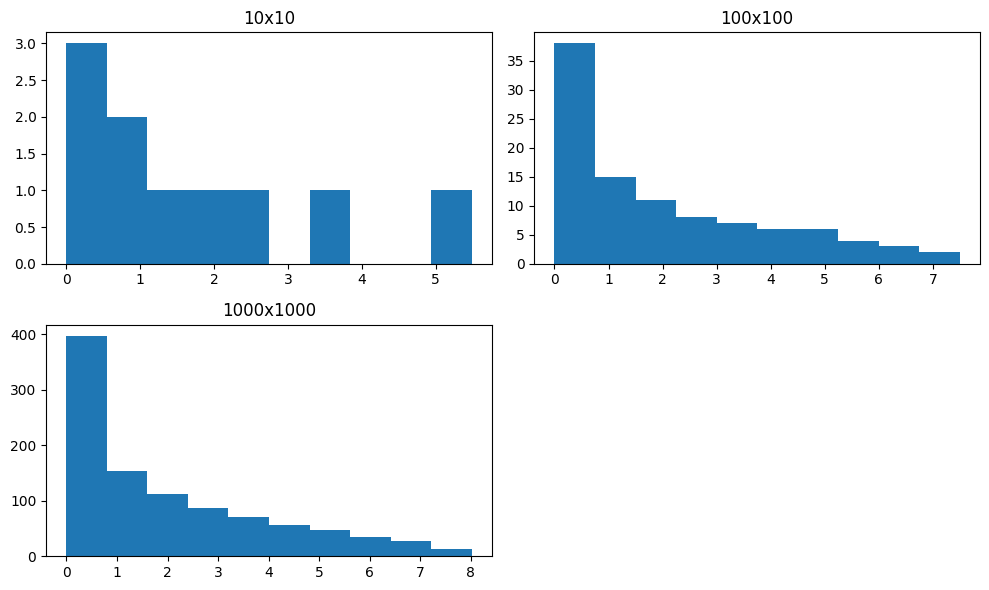

In [6]:
# subplots of spectra
plt.figure(figsize=(10, 6))
for i, spec in enumerate(spectra):
    plt.subplot(2, 2, i+1)
    plt.hist(spec)
    plt.title(f'{dim_list[i]}x{dim_list[i]}')
plt.tight_layout()
plt.show()

In [9]:
from typing import Dict, Tuple, List
import torch
import math

def sample_angle_torch(n: int, device: str = "cpu") -> float:
    """
    Sample one angle (in radians) between ∇||W||_F and ∇||W||_*,
    where W is Kaiming-uniform initialized in PyTorch.
    """
    # Create an (n x n) weight matrix
    W = torch.empty((n, n), device=device)
    torch.nn.init.kaiming_uniform_(W, a=math.sqrt(5))  # PyTorch default for Linear layers

    # SVD (full_matrices=False for speed)
    U, S, Vh = torch.linalg.svd(W, full_matrices=False)

    # Gradients
    grad_fro = W / W.norm(p="fro")
    grad_nuc = U @ Vh

    # Cosine between two matrices = cosine between flattened vectors
    inner = torch.sum(grad_fro * grad_nuc)
    cos_theta = inner / (grad_fro.norm(p="fro") * grad_nuc.norm(p="fro"))

    # Numerical safety
    cos_theta = torch.clamp(cos_theta, -1.0, 1.0)

    # Return angle in radians (convert to Python float)
    return float(torch.acos(cos_theta)), cos_theta


def estimate_angles_torch(
    dims: List[int], num_seeds: int = 20, device: str = "cpu"
) -> Dict[int, Tuple[float, float]]:
    """
    For each dimension n, run multiple seeds and compute:
    - mean angle (deg)
    - std angle (deg)
    """
    results: Dict[int, Tuple[float, float]] = {}

    for n in dims:
        angles_deg = []
        cos_thetas = []
        for _ in range(num_seeds):
            angle_rad, cos_theta = sample_angle_torch(n, device=device)
            angle_deg = float(torch.rad2deg(torch.tensor(angle_rad)))
            angles_deg.append(angle_deg)
            cos_thetas.append(cos_theta)

        angles_tensor = torch.tensor(angles_deg)
        results[n] = (float(angles_tensor.mean()), float(angles_tensor.std()), float(torch.tensor(cos_thetas).mean()))

    return results

dims = [10, 20, 50, 100, 200]
stats = estimate_angles_torch(dims, num_seeds=10)

for n, (mean_deg, std_deg, mean_cos) in stats.items():
    print(f"n={n:4d}: mean angle = {mean_deg:.2f}°, std = {std_deg:.2f}°, mean cos = {mean_cos:.2f}")

n=  10: mean angle = 33.02°, std = 2.47°, mean cos = 0.84
n=  20: mean angle = 31.53°, std = 1.56°, mean cos = 0.85
n=  50: mean angle = 31.96°, std = 0.48°, mean cos = 0.85
n= 100: mean angle = 31.94°, std = 0.15°, mean cos = 0.85
n= 200: mean angle = 31.92°, std = 0.10°, mean cos = 0.85


In [17]:
from core.bias import RidgeBias, NuclearNormBias
import torch
for i in range(10):
    linear = torch.nn.Linear(10, 10)

    # compare the grads of the l2 and nuclear bias models
    l2_bias = RidgeBias()
    nuclear_bias = NuclearNormBias()

    l2_penalty = l2_bias.forward(linear.weight) 
    nuclear_penalty = nuclear_bias.forward(linear.weight, named_params={"weight": linear.weight})
    l2_grad = torch.autograd.grad(l2_penalty, linear.weight)[0]
    nuclear_grad = torch.autograd.grad(nuclear_penalty, linear.weight)[0]

    # compute the cosine similarity between the grads
    cos = torch.nn.functional.cosine_similarity(
        l2_grad.flatten().unsqueeze(0),
        nuclear_grad.flatten().unsqueeze(0)
    )
    print("cosine similarity = ", cos.item(), "ratio l2/nuclear = ", l2_penalty.item() / nuclear_penalty.item())

cosine similarity =  0.8132991194725037 ratio l2/nuclear =  0.7645479981435427
cosine similarity =  0.816142201423645 ratio l2/nuclear =  0.6602336427503479
cosine similarity =  0.8714557886123657 ratio l2/nuclear =  0.6796871500442425
cosine similarity =  0.827344536781311 ratio l2/nuclear =  0.836685082688362
cosine similarity =  0.8494673371315002 ratio l2/nuclear =  0.7910871682878066
cosine similarity =  0.8370914459228516 ratio l2/nuclear =  0.6136163229221588
cosine similarity =  0.8455343246459961 ratio l2/nuclear =  0.665622796280618
cosine similarity =  0.8145498037338257 ratio l2/nuclear =  0.7967804155544213
cosine similarity =  0.8577067852020264 ratio l2/nuclear =  0.7339755011651533
cosine similarity =  0.8753446936607361 ratio l2/nuclear =  0.5928327904510388


In [27]:
from core.bias import RidgeBias, LassoBias
import torch
for i in range(10):

    # toy example, train a linear model with l2 and lasso penalty
    simple_net = torch.nn.Sequential(
        torch.nn.Linear(10, 10),
        torch.nn.ReLU(),
        torch.nn.Linear(10, 1),
    )

    X = torch.randn(100, 10)
    y = torch.randn(100, 1)

    # compare the grads of the l2 and nuclear bias models
    l2_bias = RidgeBias()
    lasso_bias = LassoBias()

    # set the bias parameters
    l2_bias.beta.data = torch.tensor(0.001)
    lasso_bias.alpha.data = torch.tensor(0.001)

    l2_bias.eval()
    lasso_bias.eval()

    # train the model
    optimizer = torch.optim.Adam(simple_net.parameters(), lr=0.01)
    for epoch in range(100):
        optimizer.zero_grad()
        y_pred = simple_net(X)
        loss = torch.nn.functional.mse_loss(y_pred, y)
        l2_penalty = l2_bias.forward(linear.weight) 
        lasso_penalty = lasso_bias.forward(linear.weight, named_params={"weight": linear.weight})
        loss += l2_penalty
        loss += lasso_penalty
        loss.backward()
        optimizer.step()

    
    l2_bias = RidgeBias()
    lasso_bias = LassoBias()

    flattened_params = (
            torch.cat([p.view(-1) for p in simple_net.parameters()]).detach().requires_grad_()
        )   
    l2_penalty = l2_bias.forward(flattened_params) 
    lasso_penalty = lasso_bias.forward(flattened_params)
    l2_grad = torch.autograd.grad(l2_penalty, flattened_params)[0]
    lasso_grad = torch.autograd.grad(lasso_penalty, flattened_params)[0]

    # compute the cosine similarity between the grads   
    cos = torch.nn.functional.cosine_similarity(
        l2_grad.flatten().unsqueeze(0),
        lasso_grad.flatten().unsqueeze(0)
    )
    print("cosine similarity = ", cos.item())
    print("ratio l2/lasso = ", l2_penalty.item() / lasso_penalty.item())


cosine similarity =  0.8261865377426147
ratio l2/lasso =  0.5083815139580207
cosine similarity =  0.8317606449127197
ratio l2/lasso =  0.4547864918345418
cosine similarity =  0.8219996690750122
ratio l2/lasso =  0.4613916937247041
cosine similarity =  0.8344362378120422
ratio l2/lasso =  0.702464433953559
cosine similarity =  0.8176573514938354
ratio l2/lasso =  0.5386742382634514


cosine similarity =  0.8327957391738892
ratio l2/lasso =  0.5398148370252315
cosine similarity =  0.8291133642196655
ratio l2/lasso =  0.6006707129034508
cosine similarity =  0.8349703550338745
ratio l2/lasso =  0.49608618659070197
cosine similarity =  0.8139193058013916
ratio l2/lasso =  0.44045257845811664
cosine similarity =  0.8207443952560425
ratio l2/lasso =  0.5991690344430782


In [8]:
from core.bias import RidgeBias, OrthogonalBias
import torch
from typing import Dict

def vector_to_parameter_views(vector: torch.Tensor, model: torch.nn.Module) -> Dict[str, torch.Tensor]:
    """
    Creates a dictionary of views into 'vector' that match the structure of 'model.named_parameters()'.
    The returned views are part of the same computational graph as 'vector'.
    """
    pointer = 0
    views = []
    for param in model.parameters():
        numel = param.numel()
        views.append(vector[pointer : pointer + numel].view_as(param))
        pointer += numel
    return views

for i in range(10):
    # toy example, train a linear model with l2 and lasso penalty
    simple_net = torch.nn.Sequential(
        torch.nn.Linear(10, 10),
        torch.nn.ReLU(),
        torch.nn.Linear(10, 1),
    )

    X = torch.randn(100, 10)
    y = torch.randn(100, 1)

    # compare the grads of the l2 and nuclear bias models
    l2_bias = RidgeBias()
    orthogonal_bias = OrthogonalBias()

    # set the bias parameters
    l2_bias.beta.data = torch.tensor(0.001)
    orthogonal_bias.beta.data = torch.tensor(0.001)

    l2_bias.eval()
    orthogonal_bias.eval()

    # train the model
    optimizer = torch.optim.Adam(simple_net.parameters(), lr=0.01)
    for epoch in range(100):
        optimizer.zero_grad()
        y_pred = simple_net(X)
        loss = torch.nn.functional.mse_loss(y_pred, y)
        flattened_params = torch.nn.utils.parameters_to_vector(simple_net.parameters())
        params = vector_to_parameter_views(flattened_params, simple_net)
        l2_penalty = l2_bias.forward(flattened_params) 
        orthogonal_penalty = orthogonal_bias.forward(flattened_params, structured_params=params)
        loss += l2_penalty
        loss += orthogonal_penalty
        loss.backward()
        optimizer.step()

    
    l2_bias = RidgeBias()
    orthogonal_bias = OrthogonalBias()

    flattened_params = torch.nn.utils.parameters_to_vector(simple_net.parameters()).detach().requires_grad_()
    params = vector_to_parameter_views(flattened_params, simple_net)

    l2_penalty = l2_bias.forward(flattened_params) 
    orthogonal_penalty = orthogonal_bias.forward(flattened_params, structured_params=params)
    l2_grad = torch.autograd.grad(l2_penalty, flattened_params)[0]
    orthogonal_grad = torch.autograd.grad(orthogonal_penalty, flattened_params)[0]

    # compute the cosine similarity between the grads
    cos = torch.nn.functional.cosine_similarity(
        l2_grad.flatten().unsqueeze(0),
        orthogonal_grad.flatten().unsqueeze(0)
    )
    print("cosine similarity = ", cos.item(), "ratio l2/orthogonal = ", l2_penalty.item() / orthogonal_penalty.item())

cosine similarity =  -0.9989519715309143 ratio l2/orthogonal =  2.3759113831812946
cosine similarity =  -0.99910569190979 ratio l2/orthogonal =  2.2391519174562173
cosine similarity =  -0.999068021774292 ratio l2/orthogonal =  1.9431150064593254


cosine similarity =  -0.9984003901481628 ratio l2/orthogonal =  1.737556620020442
cosine similarity =  -0.9988211393356323 ratio l2/orthogonal =  2.5185937455047616
cosine similarity =  -0.9994031190872192 ratio l2/orthogonal =  1.7667736464643367
cosine similarity =  -0.9986937046051025 ratio l2/orthogonal =  2.594098004593568
cosine similarity =  -0.9986169338226318 ratio l2/orthogonal =  2.5210369042117025
cosine similarity =  -0.9982656240463257 ratio l2/orthogonal =  2.222442748600299
cosine similarity =  -0.9989874958992004 ratio l2/orthogonal =  2.5745386661318523
